# CricketLab: Next-Match Performance Prediction

This notebook uses the player's five completed matches to predict the **Performance Potential Score for the next match**.

The system automatically calculates strike rate, economy rate, recent form, and consistency. It uses regression only. K-Means identifies player archetypes, while performance-drop detection identifies unusual declines.

The Python logic is intentionally simple and suitable for a diploma-level project.

## 1. Install and import the libraries

The first cell installs XGBoost and the Excel reader when needed. The second cell imports the required libraries.

In [1]:
%pip install openpyxl xgboost -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from xgboost import XGBRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

## 2. Read the two datasets

Place both Excel files inside a folder named `data`, beside this notebook.

In [3]:
players = pd.read_excel('data/players_improved.xlsx')
matches = pd.read_excel('data/match_performance_improved.xlsx')

# Standardize column names to prevent errors caused by spaces or capital letters.
players.columns = players.columns.str.strip().str.lower().str.replace(' ', '_')
matches.columns = matches.columns.str.strip().str.lower().str.replace(' ', '_')

required_player_columns = [
    'player_id', 'player_name', 'primary_role',
    'batting_style', 'bowling_style'
]

required_match_columns = [
    'match_performance_id', 'match_id', 'player_id', 'match_date',
    'did_bat', 'did_bowl', 'runs', 'balls_faced', 'fours', 'sixes', 'is_out',
    'balls_bowled', 'runs_conceded', 'wickets', 'dot_balls',
    'maidens', 'wides', 'no_balls', 'catches', 'run_outs', 'stumpings'
]

missing_player_columns = [column for column in required_player_columns if column not in players.columns]
missing_match_columns = [column for column in required_match_columns if column not in matches.columns]

if missing_player_columns:
    raise ValueError('Missing columns in players_improved.xlsx: ' + str(missing_player_columns))

if missing_match_columns:
    raise ValueError(
        'Missing columns in match_performance_improved.xlsx: ' + str(missing_match_columns) +
        '. Check that the correct match file is inside the data folder.'
    )

print('Players rows and columns:', players.shape)
print('Match performance rows and columns:', matches.shape)

Players rows and columns: (56, 7)
Match performance rows and columns: (2750, 25)


## 3. View and understand the data

The following cells show sample rows, column types, and statistical summaries.

In [4]:
display(players.head())
display(matches.head())

,player_id,player_name,date_of_birth,primary_role,batting_style,bowling_style,academy_join_date
0,P001,Kasun Perera,2008-09-07,Bowler,Right-hand bat,Right-arm fast,2022-08-04
1,P002,Nuwan Fernando,2007-12-02,All-Rounder,Right-hand bat,Left-arm medium,2021-05-04
2,P003,Ashan Silva,2008-11-17,All-Rounder,Left-hand bat,Right-arm leg-break,2022-12-26
3,P004,Dinuka Jayasinghe,2009-01-04,Bowler,Right-hand bat,Right-arm medium,2022-12-03
4,P005,Kavindu Madushanka,2007-11-29,All-Rounder,Left-hand bat,Right-arm off-break,2021-01-16


,match_performance_id,match_id,player_id,match_date,opponent,venue,match_result,did_bat,batting_position,runs,...,balls_bowled,runs_conceded,wickets,dot_balls,maidens,wides,no_balls,catches,run_outs,stumpings
0,MP00001,M0001,P002,2023-06-01,Eastview Panthers,Parkland Oval,Loss,1,5,36,...,18.0,22.0,2.0,7.0,0.0,2.0,0.0,0,0,0
1,MP00002,M0001,P006,2023-06-01,Eastview Panthers,Parkland Oval,Loss,1,5,31,...,6.0,7.0,2.0,2.0,0.0,1.0,0.0,0,0,0
2,MP00003,M0001,P011,2023-06-01,Eastview Panthers,Parkland Oval,Loss,1,10,20,...,24.0,23.0,2.0,12.0,0.0,1.0,0.0,0,1,0
3,MP00004,M0001,P016,2023-06-01,Eastview Panthers,Parkland Oval,Loss,1,9,21,...,18.0,17.0,2.0,10.0,0.0,0.0,0.0,0,0,0
4,MP00005,M0001,P017,2023-06-01,Eastview Panthers,Parkland Oval,Loss,1,9,15,...,6.0,6.0,2.0,4.0,0.0,1.0,0.0,0,0,0


In [5]:
players.info()
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   player_id          56 non-null     str           
 1   player_name        56 non-null     str           
 2   date_of_birth      56 non-null     datetime64[us]
 3   primary_role       56 non-null     str           
 4   batting_style      56 non-null     str           
 5   bowling_style      56 non-null     str           
 6   academy_join_date  56 non-null     datetime64[us]
dtypes: datetime64[us](2), str(5)
memory usage: 6.4 KB
<class 'pandas.DataFrame'>
RangeIndex: 2750 entries, 0 to 2749
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   match_performance_id  2750 non-null   str           
 1   match_id              2750 non-null   str           
 2   player_id             2750

In [6]:
display(players.describe(include='all').T)
display(matches.describe(include='all').T)

,count,unique,top,freq,mean,min,25%,50%,75%,max
player_id,56,56,P001,1,NaN,NaN,NaN,NaN,NaN,NaN
player_name,56,56,Kasun Perera,1,NaN,NaN,NaN,NaN,NaN,NaN
date_of_birth,56,NaN,NaN,NaN,2007-12-30 07:17:08.571428,2006-07-22 00:00:00,2007-04-26 00:00:00,2008-01-03 00:00:00,2008-10-29 06:00:00,2009-03-04 00:00:00
primary_role,56,4,Batter,20,NaN,NaN,NaN,NaN,NaN,NaN
batting_style,56,2,Right-hand bat,39,NaN,NaN,NaN,NaN,NaN,NaN
bowling_style,56,9,Right-arm medium,11,NaN,NaN,NaN,NaN,NaN,NaN
academy_join_date,56,NaN,NaN,NaN,2022-01-28 08:34:17.142857,2019-11-22 00:00:00,2021-03-24 06:00:00,2022-05-16 00:00:00,2022-10-15 06:00:00,2023-05-12 00:00:00


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
match_performance_id,2750,2750,MP00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
match_id,2750,250,M0001,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
player_id,2750,56,P006,57,NaN,NaN,NaN,NaN,NaN,NaN,NaN
match_date,2750,NaN,NaN,NaN,2024-06-16 03:27:21.600000,2023-06-01 00:00:00,2024-01-11 00:00:00,2024-06-27 12:00:00,2024-12-03 00:00:00,2025-05-24 00:00:00,NaN
opponent,2750,20,Crimson Wolves,220,NaN,NaN,NaN,NaN,NaN,NaN,NaN
venue,2750,10,Central Academy Oval,407,NaN,NaN,NaN,NaN,NaN,NaN,NaN
match_result,2750,4,Loss,1232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
did_bat,2750.0,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,0.0
batting_position,2750.0,NaN,NaN,NaN,5.579636,1.0,3.0,5.0,8.0,11.0,3.204788
runs,2750.0,NaN,NaN,NaN,30.910909,9.0,19.0,35.0,40.0,51.0,10.952744


## 4. Check and remove duplicate values

A player should have one profile, and a player should have only one record for one match.

In [7]:
print('Duplicate player rows:', players.duplicated().sum())
print('Duplicate player IDs:', players.duplicated('player_id').sum())
print('Duplicate match rows:', matches.duplicated().sum())
print('Duplicate performance IDs:', matches.duplicated('match_performance_id').sum())
print('Duplicate player-match records:', matches.duplicated(['match_id', 'player_id']).sum())

players = players.drop_duplicates().drop_duplicates('player_id')
matches = matches.drop_duplicates().drop_duplicates(['match_id', 'player_id'])

Duplicate player rows: 0
Duplicate player IDs: 0
Duplicate match rows: 0
Duplicate performance IDs: 0
Duplicate player-match records: 0


## 5. Check and handle missing values using cricket knowledge

Blank batting values are correct when `did_bat` is 0. Blank bowling values are correct when `did_bowl` is 0. They are changed to zero. Batting position remains blank for players who did not bat because it is not used by the model.

In [8]:
print('Missing values before cleaning')
display(matches.isnull().sum().to_frame('missing_values'))

batting_columns = ['runs', 'balls_faced', 'fours', 'sixes', 'is_out']
bowling_columns = ['balls_bowled', 'runs_conceded', 'wickets', 'dot_balls',
                   'maidens', 'wides', 'no_balls']

matches.loc[matches['did_bat'] == 0, batting_columns] = 0
matches.loc[matches['did_bowl'] == 0, bowling_columns] = 0

for column in batting_columns + bowling_columns:
    matches[column] = matches[column].fillna(0)

print('Missing values after domain-based cleaning')
display(matches.isnull().sum().to_frame('missing_values'))

Missing values before cleaning


,missing_values
match_performance_id,0
match_id,0
player_id,0
match_date,0
opponent,0
venue,0
match_result,0
did_bat,0
batting_position,0
runs,0


Missing values after domain-based cleaning


,missing_values
match_performance_id,0
match_id,0
player_id,0
match_date,0
opponent,0
venue,0
match_result,0
did_bat,0
batting_position,0
runs,0


## 6. Handle impossible outliers using domain knowledge

Real high cricket performances are not removed. Only impossible values are corrected, such as negative counts, more than 10 wickets, more dot balls than balls bowled, and boundary runs greater than total runs.

In [9]:
number_columns = ['runs', 'balls_faced', 'fours', 'sixes', 'balls_bowled',
                  'runs_conceded', 'wickets', 'dot_balls', 'maidens',
                  'wides', 'no_balls', 'catches', 'run_outs', 'stumpings']

for column in number_columns:
    matches[column] = matches[column].clip(lower=0)

matches['wickets'] = matches['wickets'].clip(upper=10)
matches['dot_balls'] = np.minimum(matches['dot_balls'], matches['balls_bowled'])
matches['fours'] = np.minimum(matches['fours'], matches['runs'] // 4)
remaining_runs = matches['runs'] - matches['fours'] * 4
matches['sixes'] = np.minimum(matches['sixes'], remaining_runs // 6)

print('Domain validation completed.')

Domain validation completed.


## 7. Merge player details and match performance

Both files are joined using `player_id`.

In [10]:
data = matches.merge(players, on='player_id', how='left', validate='many_to_one')

print('Merged rows and columns:', data.shape)
print('Rows without player details:', data['player_name'].isnull().sum())
display(data.head())

Merged rows and columns: (2750, 31)
Rows without player details: 0


,match_performance_id,match_id,player_id,match_date,opponent,venue,match_result,did_bat,batting_position,runs,...,no_balls,catches,run_outs,stumpings,player_name,date_of_birth,primary_role,batting_style,bowling_style,academy_join_date
0,MP00001,M0001,P002,2023-06-01,Eastview Panthers,Parkland Oval,Loss,1,5,36,...,0.0,0,0,0,Nuwan Fernando,2007-12-02,All-Rounder,Right-hand bat,Left-arm medium,2021-05-04
1,MP00002,M0001,P006,2023-06-01,Eastview Panthers,Parkland Oval,Loss,1,5,31,...,0.0,0,0,0,Shehan Gunaratne,2007-11-18,All-Rounder,Left-hand bat,Right-arm off-break,2021-01-30
2,MP00003,M0001,P011,2023-06-01,Eastview Panthers,Parkland Oval,Loss,1,10,20,...,0.0,0,1,0,Lahiru Senanayake,2006-08-10,Bowler,Right-hand bat,Right-arm leg-break,2022-11-15
3,MP00004,M0001,P016,2023-06-01,Eastview Panthers,Parkland Oval,Loss,1,9,21,...,0.0,0,0,0,Chamara Ekanayake,2007-11-16,Bowler,Left-hand bat,Right-arm leg-break,2020-12-23
4,MP00005,M0001,P017,2023-06-01,Eastview Panthers,Parkland Oval,Loss,1,9,15,...,0.0,0,0,0,Janith Abeysekara,2008-05-24,Bowler,Right-hand bat,Left-arm orthodox,2021-08-20


## 8. Exploratory data analysis

These simple charts show the role distribution, runs, wickets, and match results.

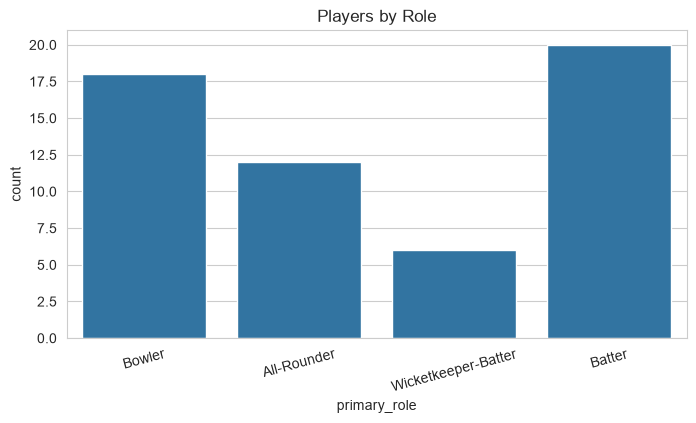

In [11]:
plt.figure(figsize=(8, 4))
sns.countplot(data=players, x='primary_role')
plt.title('Players by Role')
plt.xticks(rotation=15)
plt.show()

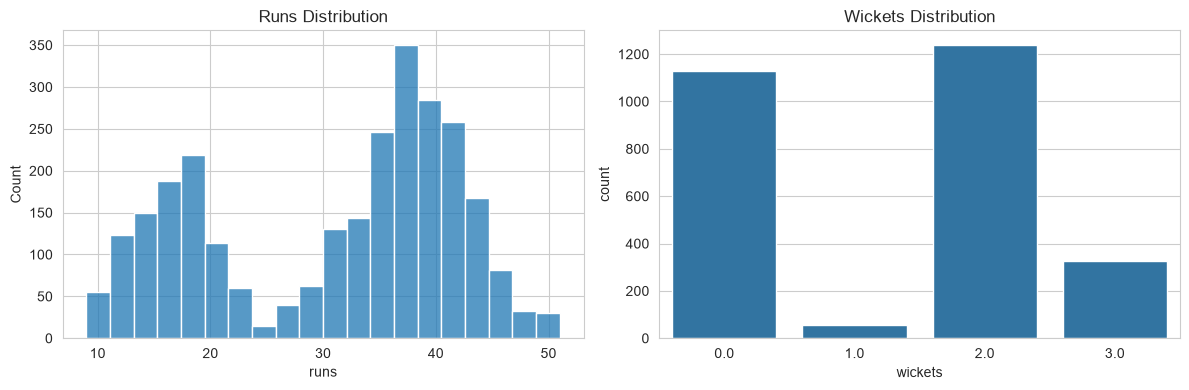

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data['runs'], bins=20, ax=axes[0])
axes[0].set_title('Runs Distribution')
sns.countplot(data=data, x='wickets', ax=axes[1])
axes[1].set_title('Wickets Distribution')
plt.tight_layout()
plt.show()

In [13]:
display(data.groupby('primary_role')[['runs', 'wickets', 'catches']].mean().round(2))

,runs,wickets,catches
primary_role,,,
All-Rounder,34.04,1.96,0.06
Batter,40.99,0.03,0.05
Bowler,16.73,2.35,0.07
Wicketkeeper-Batter,38.22,0.00,0.08


## 9. Calculate strike rate and economy rate automatically

Strike rate is runs divided by balls faced, multiplied by 100. Economy rate is runs conceded per six balls.

In [14]:
data['strike_rate'] = np.where(
    data['balls_faced'] > 0,
    data['runs'] / data['balls_faced'] * 100,
    0
)

data['economy_rate'] = np.where(
    data['balls_bowled'] > 0,
    data['runs_conceded'] / data['balls_bowled'] * 6,
    0
)

display(data[['runs', 'balls_faced', 'strike_rate',
              'runs_conceded', 'balls_bowled', 'economy_rate']].head())

,runs,balls_faced,strike_rate,runs_conceded,balls_bowled,economy_rate
0,36,28,128.571429,22.0,18.0,7.333333
1,31,25,124.000000,7.0,6.0,7.000000
2,20,19,105.263158,23.0,24.0,5.750000
3,21,20,105.000000,17.0,18.0,5.666667
4,15,15,100.000000,6.0,6.0,6.000000


## 10. Calculate the match Performance Potential Score

Batting, bowling, and fielding scores are first calculated on a 0–100 scale. Different role weights are used so batters, bowlers, all-rounders, and wicketkeeper-batters are evaluated fairly.

This is a transparent system formula used to create the regression target.

In [15]:
data['batting_score'] = (
    data['runs'] / 50 * 60 + data['strike_rate'] / 200 * 40
).clip(0, 100)

economy_points = np.where(
    data['did_bowl'] == 1,
    ((10 - data['economy_rate']).clip(0, 10) / 10) * 30,
    0
)

data['bowling_score'] = (
    data['wickets'] / 4 * 70 + economy_points
).clip(0, 100)

data['fielding_score'] = (
    data['catches'] * 20 + data['run_outs'] * 25 + data['stumpings'] * 25
).clip(0, 100)

In [16]:
def calculate_score(row):
    if row['primary_role'] == 'Bowler':
        score = row['batting_score'] * 0.10 + row['bowling_score'] * 0.70 + row['fielding_score'] * 0.20
    elif row['primary_role'] == 'All-Rounder':
        score = row['batting_score'] * 0.45 + row['bowling_score'] * 0.45 + row['fielding_score'] * 0.10
    elif row['primary_role'] == 'Wicketkeeper-Batter':
        score = row['batting_score'] * 0.65 + row['bowling_score'] * 0.05 + row['fielding_score'] * 0.30
    else:
        score = row['batting_score'] * 0.70 + row['bowling_score'] * 0.10 + row['fielding_score'] * 0.20
    return round(score, 2)

data['performance_score'] = data.apply(calculate_score, axis=1)
display(data[['player_name', 'primary_role', 'performance_score']].head(10))

,player_name,primary_role,performance_score
0,Nuwan Fernando,All-Rounder,50.36
1,Shehan Gunaratne,All-Rounder,47.70
2,Lahiru Senanayake,Bowler,42.93
3,Chamara Ekanayake,Bowler,38.22
4,Janith Abeysekara,Bowler,36.70
5,Yasiru Kulatunga,Batter,55.54
6,Chethiya Ranasinghe,Batter,51.22
7,Shenal Peris,Wicketkeeper-Batter,46.67
8,Fazil Ahamed,All-Rounder,50.64
9,Tharshan Sivarajah,Bowler,36.12


## 11. Create features from the previous five completed matches

The records are sorted by player and date. `shift(1)` removes the current match before the rolling calculation. Therefore, each row uses exactly the player's five earlier completed matches.

- `recent_form` is the average Performance Potential Score from those five matches.
- `consistency` is the standard deviation of those five scores. A smaller value means more consistent performance.
- The target is the current row's score, which represents the next match after the five input matches.

In [17]:
data['match_date'] = pd.to_datetime(data['match_date'])
data = data.sort_values(['player_id', 'match_date']).reset_index(drop=True)

previous_columns = ['runs', 'strike_rate', 'wickets', 'economy_rate',
                    'catches', 'run_outs', 'stumpings']

for column in previous_columns:
    data['last5_' + column] = data.groupby('player_id')[column].transform(
        lambda values: values.shift(1).rolling(5).mean()
    )

data['recent_form'] = data.groupby('player_id')['performance_score'].transform(
    lambda values: values.shift(1).rolling(5).mean()
)

data['consistency'] = data.groupby('player_id')['performance_score'].transform(
    lambda values: values.shift(1).rolling(5).std()
)

model_data = data.dropna(subset=['recent_form', 'consistency']).copy()

print('Rows available after requiring five previous matches:', len(model_data))
display(model_data[['player_name', 'match_date', 'recent_form',
                    'consistency', 'performance_score']].head())

Rows available after requiring five previous matches: 2470


,player_name,match_date,recent_form,consistency,performance_score
5,Kasun Perera,2023-09-18,36.488,0.247123,36.48
6,Kasun Perera,2023-10-20,36.472,0.243865,36.88
7,Kasun Perera,2023-11-02,36.600,0.259133,36.74
8,Kasun Perera,2023-11-14,36.594,0.254519,40.88
9,Kasun Perera,2023-11-29,37.526,1.880553,36.71


## 12. Select model inputs and target

The target is the next-match `performance_score`. Player IDs, names, current-match statistics, and dates are excluded from the inputs to prevent data leakage.

In [18]:
numeric_features = [
    'last5_runs', 'last5_strike_rate', 'last5_wickets',
    'last5_economy_rate', 'last5_catches', 'last5_run_outs',
    'last5_stumpings', 'recent_form', 'consistency'
]

categorical_features = ['primary_role', 'batting_style', 'bowling_style']
feature_columns = numeric_features + categorical_features

model_data = model_data.sort_values('match_date').reset_index(drop=True)
X = model_data[feature_columns]
y = model_data['performance_score']

print('Model inputs:', X.shape)
print('Model target:', y.shape)

Model inputs: (2470, 12)
Model target: (2470,)


## 13. Split 80% for training and 20% for testing

`test_size=0.20` keeps 20% of the records for final testing. `shuffle=False` preserves time order, so later matches are tested using models trained on earlier matches.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, shuffle=False
)

print('Training rows:', len(X_train))
print('Testing rows:', len(X_test))

Training rows: 1976
Testing rows: 494


## 14. Prepare numeric and category columns

Missing numeric values use the median. Category names use one-hot encoding because categories such as role and batting style do not have a numeric order.

In [20]:
numeric_process = Pipeline([
    ('missing', SimpleImputer(strategy='median'))
])

category_process = Pipeline([
    ('missing', SimpleImputer(strategy='most_frequent')),
    ('encoding', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('numbers', numeric_process, numeric_features),
    ('categories', category_process, categorical_features)
])

## 15. Model 1: Linear Regression

Linear Regression is used as the simplest model and baseline.

In [21]:
linear_model = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_prediction = linear_model.predict(X_test)

## 16. Model 2: Random Forest

Random Forest uses several decision trees and can learn non-linear cricket performance patterns.

In [22]:
random_forest_model = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=250,
        max_depth=10,
        min_samples_leaf=3,
        random_state=42
    ))
])

random_forest_model.fit(X_train, y_train)
random_forest_prediction = random_forest_model.predict(X_test)

## 17. Model 3: XGBoost

XGBoost builds trees step by step and corrects earlier errors. Only a few simple settings are used.

In [23]:
xgboost_model = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        objective='reg:squarederror',
        random_state=42
    ))
])

xgboost_model.fit(X_train, y_train)
xgboost_prediction = xgboost_model.predict(X_test)

## 18. Compare all three regression models

For this numeric prediction problem, model performance is measured using:

- **MAE:** average prediction error; lower is better.
- **RMSE:** gives more importance to larger errors; lower is better.
- **R²:** how much variation the model explains; higher is better.
- **R² Percentage:** R² multiplied by 100. This is shown as the requested regression accuracy-style percentage, but it should be called R² percentage in the report.

The results are calculated honestly. They are not changed to force an 80% result.

In [24]:
def check_model(name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)
    return [name, mae, rmse, r2, r2 * 100]

comparison = pd.DataFrame([
    check_model('Linear Regression', y_test, linear_prediction),
    check_model('Random Forest', y_test, random_forest_prediction),
    check_model('XGBoost', y_test, xgboost_prediction)
], columns=['Model', 'MAE', 'RMSE', 'R2', 'R2 Percentage'])

comparison = comparison.round(4)
display(comparison.sort_values('R2', ascending=False))

,Model,MAE,RMSE,R2,R2 Percentage
0,Linear Regression,1.8454,2.9852,0.8165,81.6493
1,Random Forest,1.7951,2.9919,0.8157,81.5673
2,XGBoost,1.8729,3.0449,0.8091,80.9082


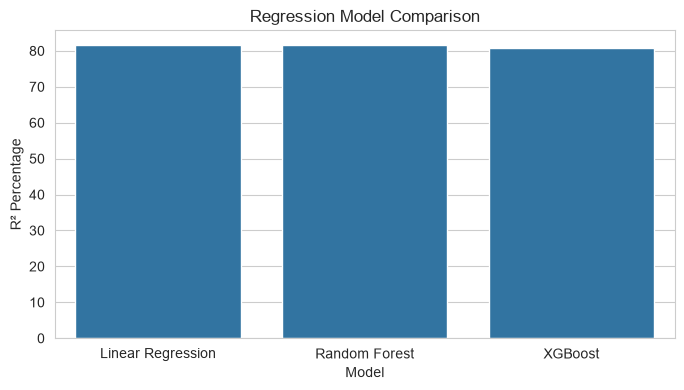

In [25]:
plt.figure(figsize=(8, 4))
sns.barplot(data=comparison, x='Model', y='R2 Percentage')
plt.title('Regression Model Comparison')
plt.ylabel('R² Percentage')
plt.show()

## 19. Select the best model

The model with the highest test R² is selected automatically. It is not saved yet. Saving is kept until the final step, after testing and the remaining analysis are completed.

In [26]:
models = {
    'Linear Regression': linear_model,
    'Random Forest': random_forest_model,
    'XGBoost': xgboost_model
}

best_model_name = comparison.sort_values('R2', ascending=False).iloc[0]['Model']
best_model = models[best_model_name]

print('Best model:', best_model_name)

Best model: Linear Regression


## 20. Test the best model using unseen test data

One record is taken from the 20% test set. The table compares its real Performance Potential Score with the score predicted by the selected model. This confirms that the complete preprocessing and prediction pipeline works on unseen data.

In [27]:
test_example = X_test.iloc[[0]]
actual_score = y_test.iloc[0]
predicted_score = best_model.predict(test_example)[0]

test_result = pd.DataFrame({
    'Actual Score': [round(actual_score, 2)],
    'Predicted Score': [round(predicted_score, 2)],
    'Absolute Error': [round(abs(actual_score - predicted_score), 2)]
})

display(test_example)
display(test_result)

,last5_runs,last5_strike_rate,last5_wickets,last5_economy_rate,last5_catches,last5_run_outs,last5_stumpings,recent_form,consistency,primary_role,batting_style,bowling_style
1976,32.4,125.644444,2.0,7.125,0.0,0.0,0.0,48.434,0.47189,All-Rounder,Left-hand bat,Right-arm medium


,Actual Score,Predicted Score,Absolute Error
0,48.62,48.51,0.11


## 21. Prepare each player's latest five matches

This creates one new input row for every player. Unlike training rows, these features include the player's latest completed match because the task is now to predict the match that comes after all available records.

In [28]:
latest_rows = []

for player_id in data['player_id'].unique():
    player_matches = data[data['player_id'] == player_id].sort_values('match_date')
    last_five = player_matches.tail(5)

    if len(last_five) == 5:
        player = players[players['player_id'] == player_id].iloc[0]
        latest_rows.append({
            'player_id': player_id,
            'player_name': player['player_name'],
            'primary_role': player['primary_role'],
            'batting_style': player['batting_style'],
            'bowling_style': player['bowling_style'],
            'last5_runs': last_five['runs'].mean(),
            'last5_strike_rate': last_five['strike_rate'].mean(),
            'last5_wickets': last_five['wickets'].mean(),
            'last5_economy_rate': last_five['economy_rate'].mean(),
            'last5_catches': last_five['catches'].mean(),
            'last5_run_outs': last_five['run_outs'].mean(),
            'last5_stumpings': last_five['stumpings'].mean(),
            'recent_form': last_five['performance_score'].mean(),
            'consistency': last_five['performance_score'].std()
        })

latest_players = pd.DataFrame(latest_rows)
print('Players ready for prediction:', len(latest_players))
display(latest_players.head())

Players ready for prediction: 56


,player_id,player_name,primary_role,batting_style,bowling_style,last5_runs,last5_strike_rate,last5_wickets,last5_economy_rate,last5_catches,last5_run_outs,last5_stumpings,recent_form,consistency
0,P001,Kasun Perera,Bowler,Right-hand bat,Right-arm fast,23.4,108.275927,2.4,6.250000,0.0,0.0,0.0,42.250,6.938490
1,P002,Nuwan Fernando,All-Rounder,Right-hand bat,Left-arm medium,37.6,132.405583,2.0,7.000000,0.0,0.0,0.0,52.018,0.638490
2,P003,Ashan Silva,All-Rounder,Left-hand bat,Right-arm leg-break,37.6,132.389163,2.0,6.466667,0.0,0.0,0.0,52.738,0.601723
3,P004,Dinuka Jayasinghe,Bowler,Right-hand bat,Right-arm medium,18.0,103.464052,2.2,6.266667,0.0,0.0,0.0,39.018,5.822394
4,P005,Kavindu Madushanka,All-Rounder,Left-hand bat,Right-arm off-break,34.8,128.947904,2.0,6.400000,0.2,0.0,0.0,51.408,1.139241


## 22. Predict the next-match Performance Potential Score for all players

The best model predicts a 0–100 score for every player who has at least five completed matches.

In [29]:
latest_players['predicted_next_match_score'] = best_model.predict(
    latest_players[feature_columns]
).clip(0, 100)

next_match_predictions = latest_players[[
    'player_id', 'player_name', 'primary_role',
    'recent_form', 'consistency', 'predicted_next_match_score'
]].copy()

next_match_predictions['predicted_next_match_score'] = (
    next_match_predictions['predicted_next_match_score'].round(2)
)

display(next_match_predictions.sort_values('predicted_next_match_score', ascending=False))

,player_id,player_name,primary_role,recent_form,consistency,predicted_next_match_score
14,P015,Ravindu Karunaratne,Batter,61.726,2.143217,61.79
34,P035,Rashmika Gamage,Batter,61.096,2.800666,61.04
26,P027,Yasiru Kulatunga,Batter,58.000,0.709965,58.47
7,P008,Chamod Bandara,Batter,58.122,0.792004,58.21
52,P053,Udara Abeyratne,Batter,57.230,1.075918,57.19
31,P032,Avishka Peiris,Batter,56.636,0.711885,56.64
39,P040,Senura Weerasekara,Batter,55.926,0.741573,56.14
51,P052,Sanjaya Premathilake,Batter,54.550,1.238103,55.19
27,P028,Chethiya Ranasinghe,Batter,54.548,0.647588,55.11
21,P022,Sahan Amarasinghe,All-Rounder,54.368,3.415848,54.47


## 23. K-Means clustering for player archetypes

K-Means groups similar players using their average runs, strike rate, wickets, economy, and fielding. StandardScaler places these measures on a comparable scale. Silhouette score selects the best number of clusters from 2 to 6.

In [30]:
player_summary = data.groupby(['player_id', 'player_name', 'primary_role']).agg(
    average_runs=('runs', 'mean'),
    average_strike_rate=('strike_rate', 'mean'),
    average_wickets=('wickets', 'mean'),
    average_economy=('economy_rate', 'mean'),
    average_fielding=('fielding_score', 'mean')
).reset_index()

cluster_columns = ['average_runs', 'average_strike_rate', 'average_wickets',
                   'average_economy', 'average_fielding']

scaler = StandardScaler()
scaled_data = scaler.fit_transform(player_summary[cluster_columns])

silhouette_values = []
for k in range(2, 7):
    test_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    test_clusters = test_model.fit_predict(scaled_data)
    silhouette_values.append([k, silhouette_score(scaled_data, test_clusters)])

silhouette_table = pd.DataFrame(
    silhouette_values, columns=['Number of Clusters', 'Silhouette Score']
)
display(silhouette_table)

,Number of Clusters,Silhouette Score
0,2,0.545364
1,3,0.510738
2,4,0.453183
3,5,0.442427
4,6,0.392178


In [31]:
best_k = int(silhouette_table.sort_values('Silhouette Score', ascending=False).iloc[0]['Number of Clusters'])

kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
player_summary['cluster'] = kmeans_model.fit_predict(scaled_data)

cluster_centres = player_summary.groupby('cluster')[cluster_columns].mean().round(2)
display(cluster_centres)

,average_runs,average_strike_rate,average_wickets,average_economy,average_fielding
cluster,,,,,
0,23.66,111.53,2.19,6.44,1.47
1,40.34,136.49,0.02,0.82,1.42


## 24. Assign simple archetype names

The archetype name is based on the strongest characteristic of each cluster. The cluster centre table above should be checked when explaining these names.

In [32]:
archetype_names = {}

for cluster in cluster_centres.index:
    centre = cluster_centres.loc[cluster]
    if centre['average_wickets'] == cluster_centres['average_wickets'].max():
        archetype = 'Bowling Specialist'
    elif centre['average_strike_rate'] == cluster_centres['average_strike_rate'].max():
        archetype = 'Power Hitter'
    elif centre['average_fielding'] == cluster_centres['average_fielding'].max():
        archetype = 'Fielding Specialist'
    elif centre['average_runs'] == cluster_centres['average_runs'].max():
        archetype = 'Anchor Batter'
    else:
        archetype = 'Developing All-Rounder'
    archetype_names[cluster] = archetype

player_summary['archetype'] = player_summary['cluster'].map(archetype_names)
display(player_summary[['player_id', 'player_name', 'primary_role', 'archetype']])

,player_id,player_name,primary_role,archetype
0,P001,Kasun Perera,Bowler,Bowling Specialist
1,P002,Nuwan Fernando,All-Rounder,Bowling Specialist
2,P003,Ashan Silva,All-Rounder,Bowling Specialist
3,P004,Dinuka Jayasinghe,Bowler,Bowling Specialist
4,P005,Kavindu Madushanka,All-Rounder,Bowling Specialist
5,P006,Shehan Gunaratne,All-Rounder,Bowling Specialist
6,P007,Dasun Wijesinghe,Wicketkeeper-Batter,Power Hitter
7,P008,Chamod Bandara,Batter,Power Hitter
8,P009,Tharindu Lakshan,Bowler,Bowling Specialist
9,P010,Isuru Dissanayake,Batter,Power Hitter


## 25. Performance-drop detection

The performance change is the current match score minus the player's previous-five-match recent form. Isolation Forest finds unusual changes. Only unusual negative changes are labelled as performance drops; unusual improvements are not treated as drops.

In [33]:
drop_data = model_data[['performance_score', 'recent_form', 'consistency']].copy()
drop_data['performance_change'] = drop_data['performance_score'] - drop_data['recent_form']

drop_model = IsolationForest(contamination=0.05, random_state=42)
drop_data['unusual_result'] = drop_model.fit_predict(
    drop_data[['performance_change', 'consistency']]
)

model_data['performance_change'] = drop_data['performance_change']
model_data['performance_drop'] = np.where(
    (drop_data['unusual_result'] == -1) & (drop_data['performance_change'] < 0),
    'Unusual Decline',
    'No Unusual Decline'
)

performance_drops = model_data[model_data['performance_drop'] == 'Unusual Decline'][[
    'player_id', 'player_name', 'match_id', 'match_date', 'primary_role',
    'recent_form', 'performance_score', 'performance_change', 'performance_drop'
]]

print('Unusual performance declines found:', len(performance_drops))
display(performance_drops.head(20))

Unusual performance declines found: 65


,player_id,player_name,match_id,match_date,primary_role,recent_form,performance_score,performance_change,performance_drop
0,P043,Fazil Ahamed,M0023,2023-08-26,All-Rounder,48.556,41.72,-6.836,Unusual Decline
38,P011,Lahiru Senanayake,M0029,2023-09-27,Bowler,47.088,36.82,-10.268,Unusual Decline
53,P009,Tharindu Lakshan,M0031,2023-10-03,Bowler,45.542,37.41,-8.132,Unusual Decline
89,P016,Chamara Ekanayake,M0034,2023-10-15,Bowler,50.118,37.41,-12.708,Unusual Decline
211,P049,Nimalan Tharmalingam,M0045,2023-11-26,All-Rounder,52.654,43.35,-9.304,Unusual Decline
264,P049,Nimalan Tharmalingam,M0050,2023-12-12,All-Rounder,50.562,42.60,-7.962,Unusual Decline
322,P011,Lahiru Senanayake,M0055,2023-12-21,Bowler,46.984,37.18,-9.804,Unusual Decline
392,P041,Mohamed Rizwan,M0062,2024-01-11,Bowler,45.666,37.29,-8.376,Unusual Decline
459,P009,Tharindu Lakshan,M0068,2024-01-20,Bowler,49.874,37.52,-12.354,Unusual Decline
579,P011,Lahiru Senanayake,M0079,2024-02-12,Bowler,47.002,36.94,-10.062,Unusual Decline


## 26. Create the final player result table

The final table combines next-match prediction, recent form, consistency, and archetype for all players.

In [34]:
final_results = next_match_predictions.merge(
    player_summary[['player_id', 'archetype']],
    on='player_id', how='left'
)

display(final_results)
final_results.to_csv('cricketlab_next_match_results.csv', index=False)

,player_id,player_name,primary_role,recent_form,consistency,predicted_next_match_score,archetype
0,P001,Kasun Perera,Bowler,42.250,6.938490,42.49,Bowling Specialist
1,P002,Nuwan Fernando,All-Rounder,52.018,0.638490,52.50,Bowling Specialist
2,P003,Ashan Silva,All-Rounder,52.738,0.601723,53.23,Bowling Specialist
3,P004,Dinuka Jayasinghe,Bowler,39.018,5.822394,39.65,Bowling Specialist
4,P005,Kavindu Madushanka,All-Rounder,51.408,1.139241,50.88,Bowling Specialist
5,P006,Shehan Gunaratne,All-Rounder,47.190,0.402182,47.56,Bowling Specialist
6,P007,Dasun Wijesinghe,Wicketkeeper-Batter,52.284,2.985771,51.97,Power Hitter
7,P008,Chamod Bandara,Batter,58.122,0.792004,58.21,Power Hitter
8,P009,Tharindu Lakshan,Bowler,51.446,2.252128,49.60,Bowling Specialist
9,P010,Isuru Dissanayake,Batter,53.200,0.748031,53.28,Power Hitter


## 27. Pickle only the best regression model

This is deliberately the final working step. Only the selected best regression pipeline is saved. K-Means, its scaler, and the performance-drop model are not pickled.

In [35]:
with open('best_cricketlab_regression_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

print('Only the best regression model was saved.')
print('Best model:', best_model_name)
print('File: best_cricketlab_regression_model.pkl')

Only the best regression model was saved.
Best model: Linear Regression
File: best_cricketlab_regression_model.pkl


## 28. Conclusion

This notebook completed the following tasks:

1. Read, checked, cleaned, and merged both datasets.
2. Calculated strike rate and economy rate automatically.
3. Created a role-aware Performance Potential Score.
4. Calculated recent form and consistency from exactly five earlier completed matches.
5. Used those five matches to predict the next-match score without using current-match inputs.
6. Compared Linear Regression, Random Forest, and XGBoost with MAE, RMSE, R², and R² percentage.
7. Tested the selected model using an unseen record from the test set.
8. Used K-Means to identify player archetypes.
9. Used Isolation Forest to identify unusual performance declines.
10. Pickled only the best regression model in the final working cell.

The complete workflow remains a regression-based next-match prediction system.